# NN-BAX (and beyond)

Working to get NN models working with Xopt, starting with (simple) MC dropout MLP. 

Xopt changes are at: https://github.com/sgasioro/Xopt/tree/nn-models

In [1]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

# need to debug some type things
torch.set_default_dtype(torch.float64)

from xopt import Xopt
from xopt.vocs import VOCS
from xopt.evaluator import Evaluator

from xopt.generators.bayesian.bax_generator import BaxGenerator
from xopt.generators.bayesian.bax.algorithms import GridOptimize

from xopt.generators.bayesian.models.ensemble import EnsembleModelConstructor # new!
from xopt.generators.bayesian.models.ensemble import MCDropoutModel # new!

## First check that model works

In [2]:
torch.manual_seed(3)
train_x = (torch.rand(5)*(2*np.pi)-np.pi)[:, None]
train_y = torch.sin(train_x)

In [3]:
prob_model = MCDropoutModel(1, 1, dropout_rate=0.05)
prob_model.fit(train_x, train_y)

In [4]:
test_x = torch.linspace(-np.pi, np.pi, 100)[:, None]
true_y = torch.sin(test_x)

In [5]:
posterior = prob_model.posterior(test_x)

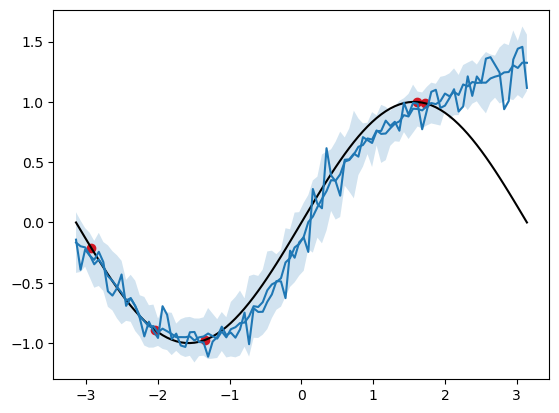

In [6]:
plt.plot(test_x, true_y, c='k')
plt.scatter(train_x, train_y, c='r')

mean = posterior.mean.cpu().detach().flatten()
std = torch.sqrt(posterior.variance.cpu().detach().flatten())

plt.plot(test_x.flatten(), mean, c='C0')
plt.fill_between(test_x.flatten(), mean-2*std, mean+2*std, fc='C0', alpha=0.2)
plt.plot(test_x.flatten(), posterior.rsample(torch.Size([1])).detach().squeeze())
plt.show()

## Then try acquisition

In [7]:
# Prepare BAX algorithm and generator options
algorithm = GridOptimize(n_mesh_points=50)  # NOTE: default is to minimize

In [9]:
# define variables and function objectives
vocs = VOCS(
    variables={"x": [-math.pi, math.pi]},
    observables=["y1"],
)

# define a test function to optimize
def sin_function(input_dict):
    return {"y1": np.sin(input_dict["x"])}


# Maybe we rename to model_constructor?
generator = BaxGenerator(gp_constructor=EnsembleModelConstructor(model=MCDropoutModel(1, 1, 
                                                                                      dropout_rate=0.4, 
                                                                                      n_cond_epochs=100)),
                         vocs=vocs, algorithm =algorithm)

In [10]:
# construct evaluator
evaluator = Evaluator(function=sin_function)

# construct Xopt optimizer
X = Xopt(evaluator=evaluator, generator=generator, vocs=vocs)

In [11]:
# evaluate initial points
X.random_evaluate(3)

# inspect the gathered data
X.data

,x,y1,xopt_runtime,xopt_error
0,-1.432109,-0.990398,0.000018,False
1,-0.558645,-0.530038,0.000004,False
2,-0.494848,-0.474898,0.000002,False


In [14]:
def plot_bax(X):
    # get the Gaussian process model from the generator
    model = X.generator.train_model()

    # get acquisition function from generator
    acq = X.generator.get_acquisition(model)

    # calculate model posterior and acquisition function at each test point
    # NOTE: need to add a dimension to the input tensor for evaluating the
    # posterior and another for the acquisition function, see
    # https://botorch.org/docs/batching for details
    # NOTE: we use the `torch.no_grad()` environment to speed up computation by
    # skipping calculations for backpropagation
    with torch.no_grad():
        posterior = model.posterior(test_x.unsqueeze(1))
        acq_val = acq(test_x.reshape(-1, 1, 1))

    # get mean function and confidence regions
    mean = posterior.mean
    L, u = posterior.mvn.confidence_region()

    # plot model and acquisition function
    fig, ax = plt.subplots(3, 1, sharex="all")
    fig.set_size_inches(8, 6)

    # plot model posterior
    ax[0].plot(test_x, mean, label="Posterior mean")
    ax[0].fill_between(test_x, L, u, alpha=0.25, label="Posterior confidence region")

    # add data to model plot
    ax[0].plot(X.data["x"], X.data["y1"], "C1o", label="Training data")

    # plot true function
    true_f = sin_function({"x": test_x})["y1"]
    ax[0].plot(test_x, true_f, "--", label="Ground truth")

    # plot the function samples and their optima found by BAX
    test_points = X.generator.algorithm_results["test_points"]
    posterior_samples = X.generator.algorithm_results["posterior_samples"]
    execution_paths = X.generator.algorithm_results["execution_paths"]

    label1 = "Function Samples"
    label2 = "Sample Optima"
    for i in range(X.generator.algorithm.n_samples):
        (samples,) = ax[1].plot(
            test_points, posterior_samples[i], c="C0", alpha=0.3, label=label1
        )
        ax[1].scatter(
            *execution_paths[i], c="r", marker="x", s=80, label=label2, zorder=10
        )
        label1 = None
        label2 = None

    # plot acquisition function
    ax[2].plot(test_x, acq_val.flatten())

    ax[0].set_ylabel("y1")
    ax[1].set_ylabel("y1")
    ax[2].set_ylabel(r"$\alpha(x)$")
    ax[2].set_xlabel("x")

    return fig, ax

/lscratch/sgaz/tmp/ipykernel_4033591/515661921.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"y1": np.sin(input_dict["x"])}
/lscratch/sgaz/tmp/ipykernel_4033591/515661921.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"y1": np.sin(input_dict["x"])}
/lscratch/sgaz/tmp/ipykernel_4033591/515661921.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"y1": np.sin(input_dict["x"])}
/lscratch/sgaz/tmp/ipykernel_4033591/515661921.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"y1": np.sin(input_dict["x"])}


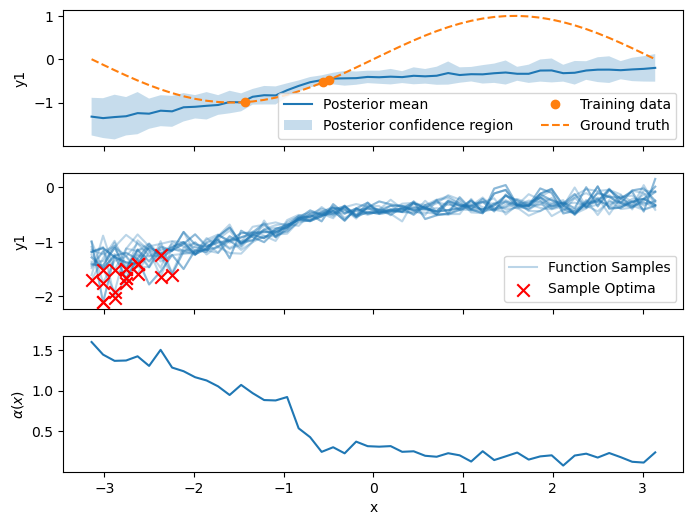

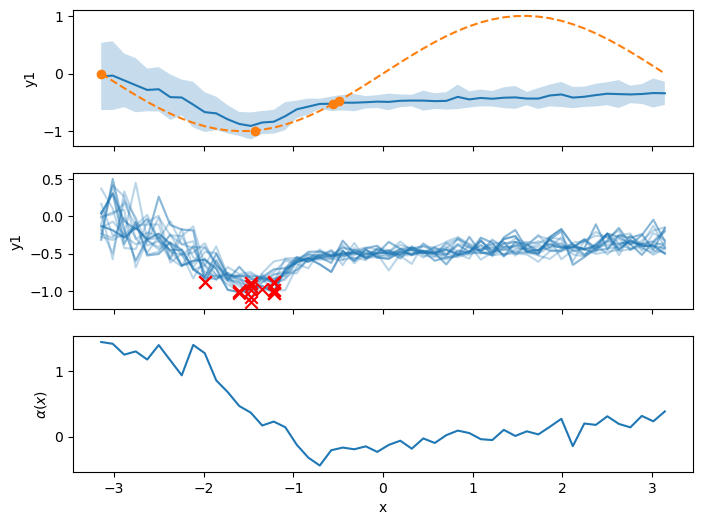

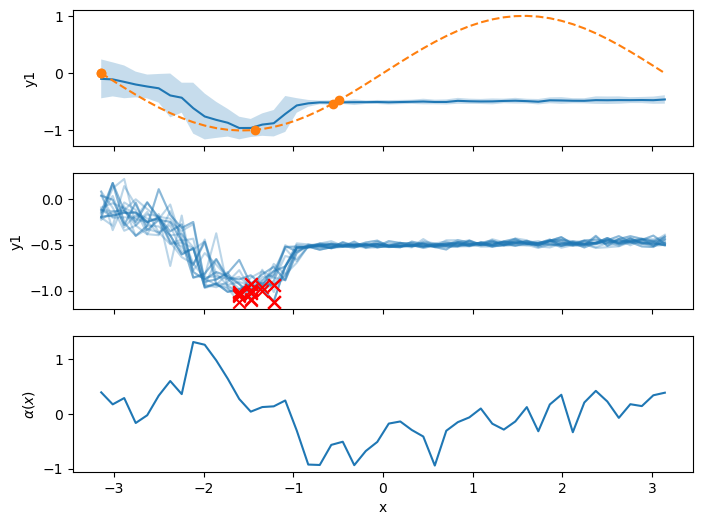

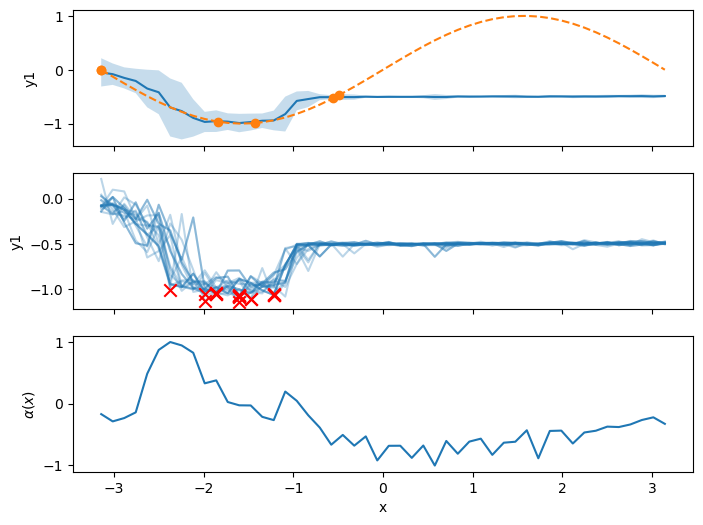

In [15]:
# NB: There's a mismatch in acquisition value between plot and acquired because of different model trainings
n_steps = 4

# test points for plotting
test_x = torch.linspace(*X.vocs.bounds.flatten(), 50).double()

for i in range(n_steps):
    # plot model and bax information
    fig, ax = plot_bax(X)

    if i == 0:
        ax[0].legend(ncols=2)
        ax[1].legend()

    # do the optimization step
    X.step()